**1. Một vài lưu ý**

-Trước tiên hãy khảo sát raw data

In [1]:
import pandas as pd

file_path = "project_heart_disease.csv"
df = pd.read_csv(file_path)

missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0] 

missing_values


Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
BMI                       22
Alcohol Consumption     2586
Stress Level              22
dtype: int64

- Dễ thấy với bộ dữ liệu 10k dòng mà có tới hớn 25% dữ liệu của cột Alcohol Consumption bị miss chúng ta cần xem xét tình trạng bệnh tim thông qua giới tính có bị ảnh hưởng bởi mức độ tiêu thụ rượu, bia hay không

In [2]:
import scipy.stats as stats

contingency_table = pd.crosstab(df["Alcohol Consumption"], df["Gender"])

chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("p value = ", p_value)

p value =  0.11391335535327167


Vì p-value > 0.05, chúng ta không có đủ bằng chứng để kết luận rằng có mối quan hệ có ý nghĩa thống kê giữa giới tính và mức độ tiêu thụ rượu. Nói cách khác, vấn đề tim mạch do tiêu thụ rượu dường như không bị ảnh hưởng đáng kể bởi giới tính trong tập dữ liệu này.


In [4]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Đọc dữ liệu
df = pd.read_csv("project_heart_disease.csv")  # Thay 'data.csv' bằng file dữ liệu của bạn

# Điền missing values cho các cột số bằng median
for col in ["Age", "Blood Pressure", "Cholesterol Level", "BMI"]:
    if df[col].dtype in ['int64', 'float64']:  # Chỉ xử lý cột số
        df[col].fillna(df[col].median(), inplace=True)

# Chuyển đổi "Stress Level" từ categorical sang numeric
mapping = {"Low": 1, "Medium": 2, "High": 3}
df["Stress Level"] = df["Stress Level"].map(mapping)
df["Stress Level"].fillna(df["Stress Level"].median(), inplace=True)

# Điền missing values cho các cột categorical bằng mode
for col in ["Gender", "Exercise Habits", "Smoking", "Family Heart Disease"]:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Biến đổi dữ liệu categorical thành dạng số để KNN có thể xử lý
label_encoders = {}
for col in ["Gender", "Exercise Habits", "Smoking", "Family Heart Disease", "Stress Level"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le 

imputer = KNNImputer(n_neighbors=5)
df["Alcohol Consumption"] = imputer.fit_transform(df[["Age", "Blood Pressure", "Cholesterol Level", "BMI", "Stress Level"]])


# Chuyển lại các biến đã chuyển thành số về dạng category trước khi lưu vào file
for col in ["Gender", "Exercise Habits", "Smoking", "Family Heart Disease", "Stress Level"]:
    df[col] = label_encoders[col].inverse_transform(df[col])

# Save the cleaned data
df.to_csv("output.csv", index=False, encoding="utf-8")

print("Data imputation completed successfully!")

Data imputation completed successfully!


C:\Users\NGOHAIBANG\AppData\Local\Temp\ipykernel_34212\1978142162.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\NGOHAIBANG\AppData\Local\Temp\ipykernel_34212\1978142162.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy

C:\Users\NGOHAIBANG\AppData\Local\Temp\ipykernel_34212\2962769207.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heart_disease_counts = df.groupby('Age Group')['Heart Disease Status'].sum()


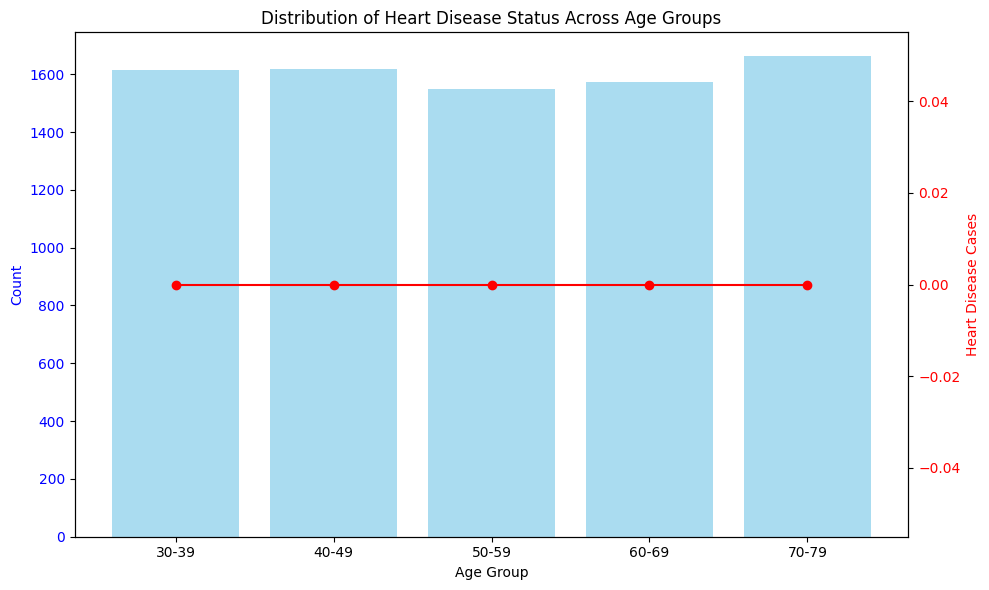

In [ ]:
import matplotlib.pyplot as plt

df['Heart Disease Status'] = df['Heart Disease Status'].map({'Yes': 1, 'No': 0})

# Xác định nhóm tuổi
bins = list(range(30, 81, 10))  # Nhóm tuổi: 30-39, 40-49, ..., 70-79
labels = [f"{b}-{b+9}" for b in bins[:-1]]

# Phân nhóm tuổi
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Đếm số lượng người trong mỗi nhóm tuổi
age_group_counts = df['Age Group'].value_counts().sort_index()

# Tính tổng số ca bệnh tim trong mỗi nhóm tuổi
heart_disease_counts = df.groupby('Age Group')['Heart Disease Status'].sum()

# Vẽ biểu đồ
fig, ax1 = plt.subplots(figsize=(10, 6))

# Biểu đồ histogram cho nhóm tuổi
ax1.bar(age_group_counts.index, age_group_counts.values, color='skyblue', alpha=0.7, label='Age Group Count')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Count', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Biểu đồ đường cho số ca bệnh tim
ax2 = ax1.twinx()
ax2.plot(heart_disease_counts.index, heart_disease_counts.values, marker='o', color='red', label='Heart Disease Cases')
ax2.set_ylabel('Heart Disease Cases', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Distribution of Heart Disease Status Across Age Groups')
fig.tight_layout()
plt.show()